In [ ]:
# Install required packages
%pip install polars pandas matplotlib seaborn scikit-learn scipy

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [ ]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import linkage, dendrogram

sns.set_style("whitegrid")
RANDOM_STATE = 42
print("\u2713 Libraries loaded")

✓ Libraries loaded


In [ ]:
judges = pl.read_csv("/Workspace/Users/sumedha190198@gmail.com/judicial-backlog/judges_clean.csv")
lf_sample = pl.scan_parquet("/Workspace/Users/sumedha190198@gmail.com/judicial-backlog/cases_sample_10pct.parquet")

judges = judges.with_columns([
    pl.col("start_date").str.to_date("%d-%m-%Y", strict=False).alias("judge_start"),
    pl.col("end_date").str.to_date("%d-%m-%Y", strict=False).alias("judge_end"),
])
judges_valid = judges.filter(pl.col("judge_start").is_not_null())
judges_lazy = judges_valid.lazy()

lf_filtered = (
    lf_sample
    .filter((pl.col("duration_days") >= 0) & (pl.col("duration_days") <= 7300))
    .join(judges_lazy.select(["state_code", "dist_code", "court_no", "judge_position", "judge_start"]),
          on=["state_code", "dist_code", "court_no", "judge_position"], how="left")
    .with_columns([(pl.col("filing_date").dt.year() - pl.col("judge_start").dt.year()).alias("judge_tenure_years")])
    .filter(pl.col("judge_start").is_not_null())
    .filter(pl.col("filing_date") >= pl.col("judge_start"))
    .filter(pl.col("judge_tenure_years") >= 0)
    .filter(pl.col("judge_tenure_years") <= 50)
)

print("\u2713 Data loaded and validated (same rules as Notebooks 4/5/9)")

✓ Data loaded and validated (same rules as Notebooks 4/5/9)


In [ ]:
schema_cols = lf_filtered.collect_schema().names()

agg_exprs = [
    pl.len().alias("case_volume"),
    pl.col("duration_days").mean().alias("avg_duration"),
    pl.col("duration_days").median().alias("median_duration"),
    (pl.col("duration_days") > 730).cast(pl.Float64).mean().alias("long_running_rate"),
    pl.col("judge_tenure_years").mean().alias("avg_tenure"),
]
if "censored" in schema_cols:
    agg_exprs.append(pl.col("censored").cast(pl.Float64).mean().alias("pending_rate"))

df_dist = (
    lf_filtered
    .group_by(["state_code", "dist_code"])
    .agg(agg_exprs)
    .collect()
    .to_pandas()
)

# Cast unsupported integer types to int64 for display compatibility
for col in df_dist.columns:
    if str(df_dist[col].dtype) in ('int32', 'uint32'):
        df_dist[col] = df_dist[col].astype('int64')

# keep districts with enough cases for stable statistics
df_dist = df_dist[df_dist["case_volume"] >= 100].reset_index(drop=True)

# derived: log volume (skew) used for clustering
df_dist["log_volume"] = np.log1p(df_dist["case_volume"])

if "pending_rate" not in df_dist.columns:
    # fallback if 'censored' is absent: proxy pending pressure with long-running share
    df_dist["pending_rate"] = df_dist["long_running_rate"]

print(f"\u2713 District feature table built: {len(df_dist)} districts")
display(df_dist.head(10))

✓ District feature table built: 474 districts


state_code,dist_code,case_volume,avg_duration,median_duration,long_running_rate,avg_tenure,pending_rate,log_volume
1,34,36268,428.96597551560603,182.0,0.21225322598433882,4.380914304621154,0.0,10.498718660901549
20,10,980,418.94591836734696,312.0,0.16938775510204082,2.716326530612245,0.0,6.8885724595653635
22,10,6018,271.95879029577935,155.0,0.10485211033565969,2.7457627118644066,0.0,8.70267641154777
23,16,13731,232.73330420217027,3.0,0.11098973126502075,2.1987473599883476,0.0,9.527484154577582
13,73,6706,151.28884580972263,19.0,0.05219206680584551,1.2314345362362065,0.0,8.810907036099737
8,29,921,80.09229098805646,35.0,0.00760043431053203,1.287730727470141,0.0,6.826545223556594
14,4,1610,220.50496894409937,40.0,0.09503105590062112,2.3229813664596275,0.0,7.384610383176974
9,2,7982,172.28388874968678,22.0,0.06539714357303934,1.4031571034828363,0.0,8.9850695596458
9,3,7764,128.1075476558475,0.0,0.06246780010303967,2.223467284904688,0.0,8.957381735582787
13,51,668,177.1811377245509,31.0,0.05688622754491018,1.345808383233533,0.0,6.505784060128229


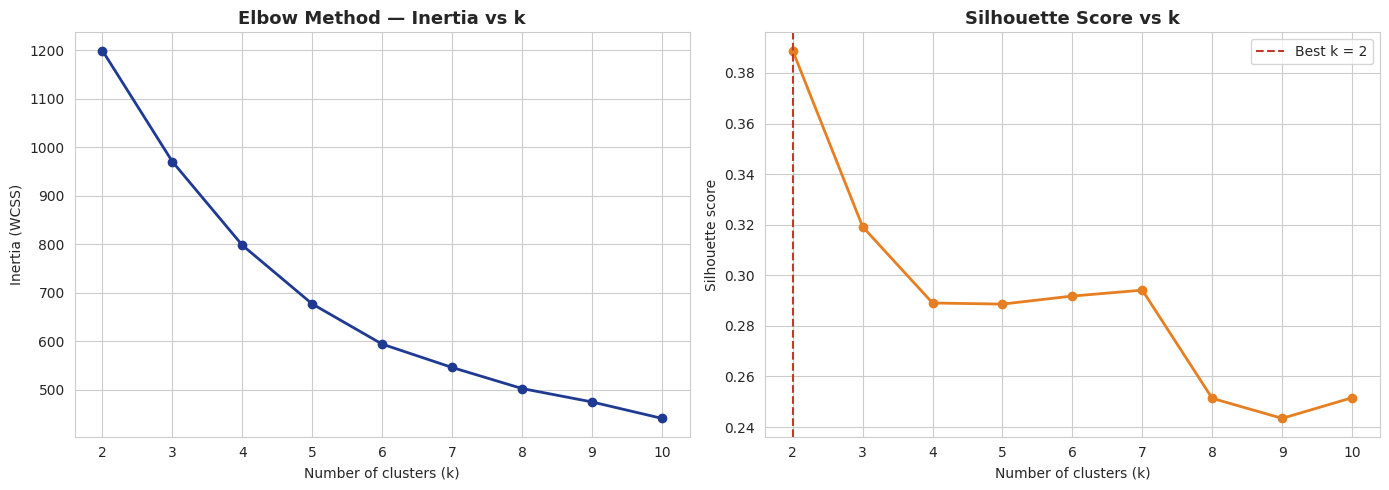

✓ Suggested k (max silhouette) = 2


In [ ]:
feature_cols = ["log_volume", "avg_duration", "pending_rate", "avg_tenure", "long_running_rate"]
feature_cols = [c for c in feature_cols if c in df_dist.columns]

X = df_dist[feature_cols].fillna(0).values
X_scaled = StandardScaler().fit_transform(X)

ks = list(range(2, 11))
inertia, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_scaled, labels))

best_k = ks[int(np.argmax(sil))]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(ks, inertia, "o-", color="#1F3A93", linewidth=2)
ax[0].set_title("Elbow Method — Inertia vs k", fontsize=13, weight="bold")
ax[0].set_xlabel("Number of clusters (k)"); ax[0].set_ylabel("Inertia (WCSS)")
ax[1].plot(ks, sil, "o-", color="#E67E22", linewidth=2)
ax[1].axvline(best_k, color="#C0392B", linestyle="--", label=f"Best k = {best_k}")
ax[1].set_title("Silhouette Score vs k", fontsize=13, weight="bold")
ax[1].set_xlabel("Number of clusters (k)"); ax[1].set_ylabel("Silhouette score")
ax[1].legend()
plt.tight_layout(); plt.show()

print(f"\u2713 Suggested k (max silhouette) = {best_k}")

In [ ]:
kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_STATE)
df_dist["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

profile_cols = ["case_volume", "avg_duration", "pending_rate", "avg_tenure", "long_running_rate"]
profile_cols = [c for c in profile_cols if c in df_dist.columns]
profile = df_dist.groupby("kmeans_cluster")[profile_cols].mean().round(2)
profile["n_districts"] = df_dist.groupby("kmeans_cluster").size()
print("K-Means cluster profile (feature means):")
display(profile)

K-Means cluster profile (feature means):


case_volume,avg_duration,pending_rate,avg_tenure,long_running_rate,n_districts
6537.94,168.81,0.0,1.93,0.06,329
21942.59,362.96,0.0,2.94,0.17,145


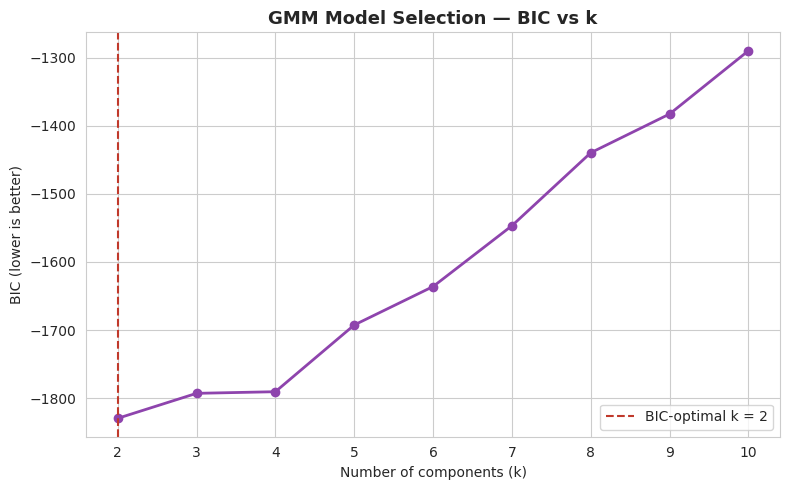

✓ GMM fitted with k=2 (BIC-optimal was 2)
  Mean assignment confidence: 0.94


In [ ]:
bic = []
for k in ks:
    gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=RANDOM_STATE)
    gmm.fit(X_scaled)
    bic.append(gmm.bic(X_scaled))

best_k_gmm = ks[int(np.argmin(bic))]

gmm = GaussianMixture(n_components=best_k, covariance_type="full", random_state=RANDOM_STATE)
gmm.fit(X_scaled)
probs = gmm.predict_proba(X_scaled)
df_dist["gmm_cluster"] = probs.argmax(axis=1)
df_dist["gmm_confidence"] = probs.max(axis=1).round(3)

plt.figure(figsize=(8, 5))
plt.plot(ks, bic, "o-", color="#8E44AD", linewidth=2)
plt.axvline(best_k_gmm, color="#C0392B", linestyle="--", label=f"BIC-optimal k = {best_k_gmm}")
plt.title("GMM Model Selection — BIC vs k", fontsize=13, weight="bold")
plt.xlabel("Number of components (k)"); plt.ylabel("BIC (lower is better)")
plt.legend(); plt.tight_layout(); plt.show()

print(f"\u2713 GMM fitted with k={best_k} (BIC-optimal was {best_k_gmm})")
print(f"  Mean assignment confidence: {df_dist['gmm_confidence'].mean():.2f}")

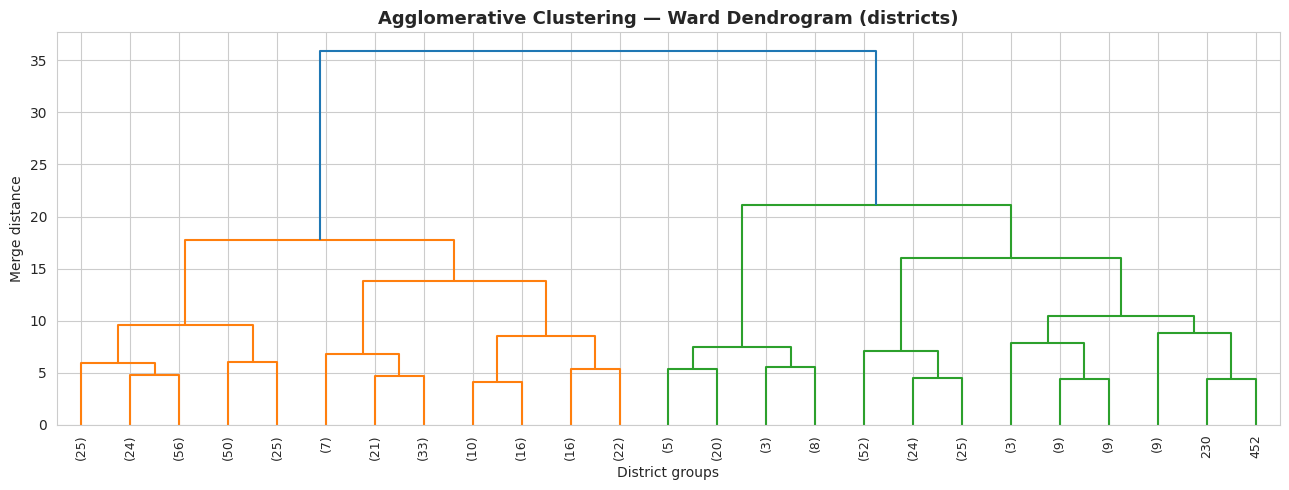

✓ Agglomerative vs K-Means agreement (Adjusted Rand Index) = 0.658


In [ ]:
agg = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
df_dist["agg_cluster"] = agg.fit_predict(X_scaled)

ari = adjusted_rand_score(df_dist["kmeans_cluster"], df_dist["agg_cluster"])

Z = linkage(X_scaled, method="ward")
plt.figure(figsize=(13, 5))
dendrogram(Z, truncate_mode="lastp", p=25, leaf_rotation=90, leaf_font_size=9,
           color_threshold=0.7 * max(Z[:, 2]))
plt.title("Agglomerative Clustering — Ward Dendrogram (districts)", fontsize=13, weight="bold")
plt.xlabel("District groups"); plt.ylabel("Merge distance")
plt.tight_layout(); plt.show()

print(f"\u2713 Agglomerative vs K-Means agreement (Adjusted Rand Index) = {ari:.3f}")

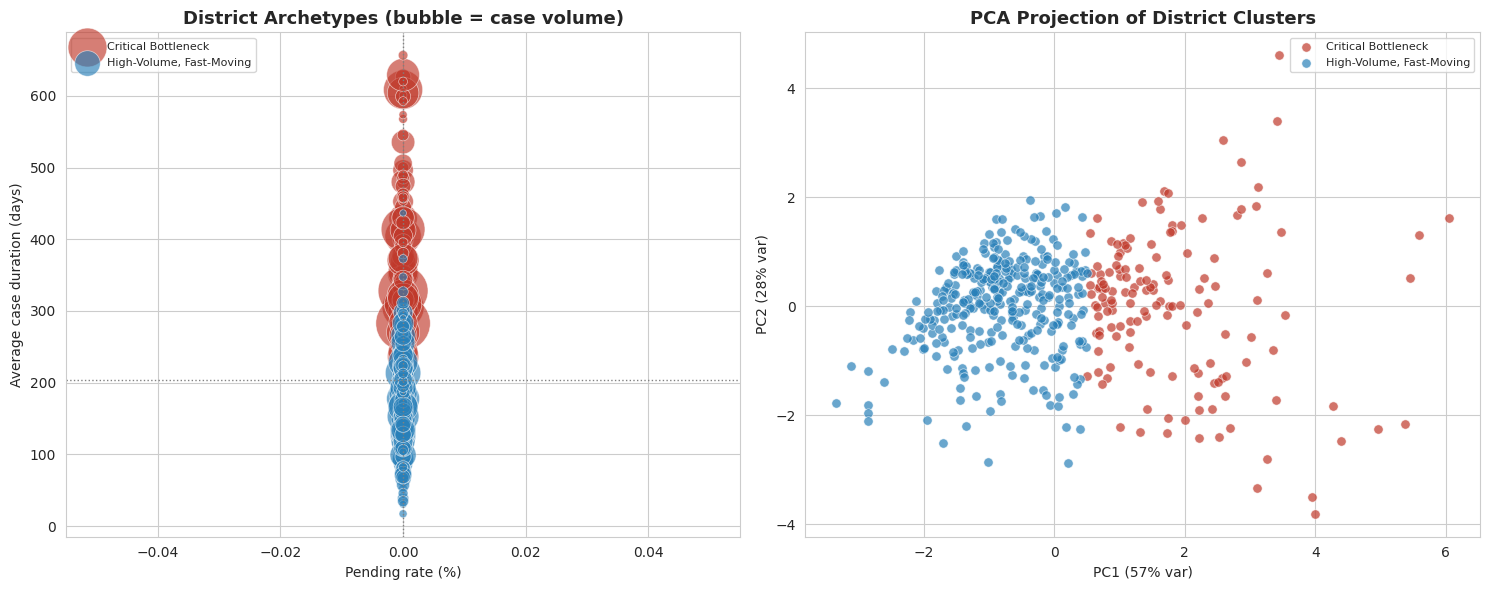

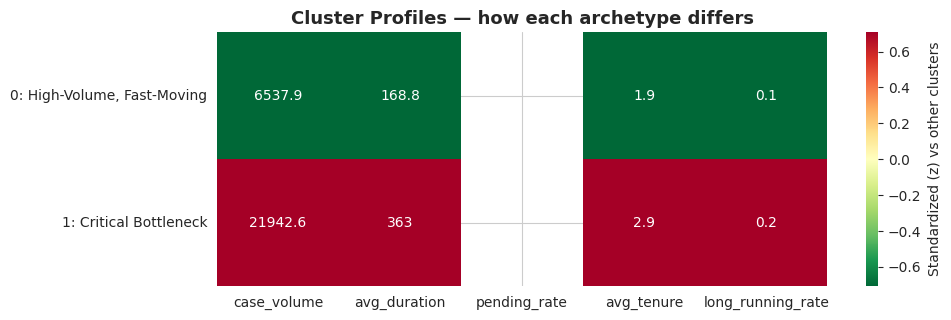

✓ Archetypes assigned:
   Cluster 0: High-Volume, Fast-Moving  (329 districts)
   Cluster 1: Critical Bottleneck  (145 districts)


In [ ]:
med_pending = df_dist["pending_rate"].median()
med_dur = df_dist["avg_duration"].median()
med_vol = df_dist["case_volume"].median()

def archetype(row):
    hp = row["pending_rate"] >= med_pending
    hd = row["avg_duration"] >= med_dur
    hv = row["case_volume"] >= med_vol
    if hp and hd:      return "Critical Bottleneck"
    if hd and not hp:  return "Slow but Contained"
    if hv and not hd:  return "High-Volume, Fast-Moving"
    return "Healthy / Low-Load"

cluster_means = df_dist.groupby("kmeans_cluster")[profile_cols].mean()
cluster_name = {c: archetype(cluster_means.loc[c]) for c in cluster_means.index}
df_dist["archetype"] = df_dist["kmeans_cluster"].map(cluster_name)

palette = {
    "Critical Bottleneck": "#C0392B",
    "Slow but Contained": "#E67E22",
    "High-Volume, Fast-Moving": "#2980B9",
    "Healthy / Low-Load": "#27AE60",
}

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

for name, g in df_dist.groupby("archetype"):
    ax[0].scatter(g["pending_rate"] * 100, g["avg_duration"],
                  s=np.sqrt(g["case_volume"]) * 2.2, alpha=0.65,
                  color=palette.get(name, "#555"), edgecolors="white", linewidth=0.5, label=name)
ax[0].axvline(med_pending * 100, color="grey", linestyle=":", linewidth=1)
ax[0].axhline(med_dur, color="grey", linestyle=":", linewidth=1)
ax[0].set_xlabel("Pending rate (%)"); ax[0].set_ylabel("Average case duration (days)")
ax[0].set_title("District Archetypes (bubble = case volume)", fontsize=13, weight="bold")
ax[0].legend(fontsize=8, loc="upper left")

pca = PCA(n_components=2, random_state=RANDOM_STATE)
XY = pca.fit_transform(X_scaled)
for name, idx in df_dist.groupby("archetype").groups.items():
    ii = df_dist.index.get_indexer(idx)
    ax[1].scatter(XY[ii, 0], XY[ii, 1], s=45, alpha=0.7,
                  color=palette.get(name, "#555"), edgecolors="white", linewidth=0.5, label=name)
ev = pca.explained_variance_ratio_ * 100
ax[1].set_xlabel(f"PC1 ({ev[0]:.0f}% var)"); ax[1].set_ylabel(f"PC2 ({ev[1]:.0f}% var)")
ax[1].set_title("PCA Projection of District Clusters", fontsize=13, weight="bold")
ax[1].legend(fontsize=8, loc="best")

plt.tight_layout(); plt.show()

# standardized profile heatmap
z = (cluster_means - cluster_means.mean()) / cluster_means.std()
z.index = [f"{c}: {cluster_name[c]}" for c in z.index]
plt.figure(figsize=(10, 0.9 * len(z) + 1.5))
sns.heatmap(z, annot=cluster_means.round(1), fmt="g", cmap="RdYlGn_r", center=0,
            cbar_kws={"label": "Standardized (z) vs other clusters"})
plt.title("Cluster Profiles — how each archetype differs", fontsize=13, weight="bold")
plt.tight_layout(); plt.show()

print("\u2713 Archetypes assigned:")
for c, n in cluster_name.items():
    print(f"   Cluster {c}: {n}  ({(df_dist['kmeans_cluster']==c).sum()} districts)")

In [ ]:
state_mapping = {
    1:"Jammu & Kashmir",2:"Himachal Pradesh",3:"Punjab",4:"Chandigarh",5:"Uttarakhand",
    6:"Haryana",7:"Delhi",8:"Rajasthan",9:"Uttar Pradesh",10:"Bihar",11:"Sikkim",
    12:"Arunachal Pradesh",13:"Nagaland",14:"Manipur",15:"Mizoram",16:"Tripura",
    17:"Meghalaya",18:"Assam",19:"West Bengal",20:"Jharkhand",21:"Odisha",
    22:"Chhattisgarh",23:"Madhya Pradesh",24:"Gujarat",25:"Daman & Diu",
    26:"Dadra & Nagar Haveli",27:"Maharashtra",28:"Andhra Pradesh",29:"Karnataka",
    30:"Goa",31:"Lakshadweep",32:"Kerala",33:"Tamil Nadu",34:"Puducherry",
    35:"Andaman & Nicobar Islands",36:"Telangana",
}
df_dist["state_name"] = df_dist["state_code"].map(state_mapping).fillna("State-" + df_dist["state_code"].astype(str))
df_dist["district_label"] = df_dist["state_name"] + " (D-" + df_dist["dist_code"].astype(str) + ")"

action = {
    "Critical Bottleneck": "Deploy 15+ yr / top-decile judges + fast-track high-impact case types",
    "Slow but Contained": "Procedural fast-track for the slow case types; monitor pending inflow",
    "High-Volume, Fast-Moving": "Protect capacity; use ML early-warning screen to keep duration low",
    "Healthy / Low-Load": "Best-practice source; rotate mentors out to bottleneck districts",
}

print("=" * 70)
print("DISTRICT SEGMENTATION — SUMMARY")
print("=" * 70)
for name in ["Critical Bottleneck", "Slow but Contained", "High-Volume, Fast-Moving", "Healthy / Low-Load"]:
    sub = df_dist[df_dist["archetype"] == name]
    if len(sub) == 0:
        continue
    print(f"\n\u25A0 {name}  ({len(sub)} districts)")
    print(f"   avg pending {sub['pending_rate'].mean()*100:.1f}%  |  avg duration {sub['avg_duration'].mean():.0f} days  |  avg tenure {sub['avg_tenure'].mean():.1f} yrs")
    print(f"   ACTION: {action[name]}")

print("\n" + "=" * 70)
print("TOP CRITICAL-BOTTLENECK DISTRICTS (act first):")
crit = df_dist[df_dist["archetype"] == "Critical Bottleneck"].sort_values("pending_rate", ascending=False)
display(crit[["district_label", "case_volume", "avg_duration", "pending_rate", "avg_tenure", "gmm_confidence"]].head(15))

out_path = "/Workspace/Users/sumedha190198@gmail.com/judicial-backlog/district_clusters.csv"
df_dist.to_csv(out_path, index=False)
print(f"\n\u2713 Labelled district table saved to: {out_path}")

DISTRICT SEGMENTATION — SUMMARY

■ Critical Bottleneck  (145 districts)
   avg pending 0.0%  |  avg duration 363 days  |  avg tenure 2.9 yrs
   ACTION: Deploy 15+ yr / top-decile judges + fast-track high-impact case types

■ High-Volume, Fast-Moving  (329 districts)
   avg pending 0.0%  |  avg duration 169 days  |  avg tenure 1.9 yrs
   ACTION: Protect capacity; use ML early-warning screen to keep duration low

TOP CRITICAL-BOTTLENECK DISTRICTS (act first):


district_label,case_volume,avg_duration,pending_rate,avg_tenure,gmm_confidence
Jammu & Kashmir (D-34),36268,428.96597551560603,0.0,4.380914304621154,0.973
Madhya Pradesh (D-14),16135,415.2267740935854,0.0,2.4233033777502326,0.961
Bihar (D-10),254,573.6692913385826,0.0,1.6299212598425197,1.0
Madhya Pradesh (D-4),7022,313.51509541441186,0.0,3.117772714326403,0.867
Jammu & Kashmir (D-5),6888,351.0876887340302,0.0,3.920150987224158,0.797
Chandigarh (D-12),2572,297.9945567651633,0.0,2.5979782270606533,0.563
Madhya Pradesh (D-26),14905,260.6341496142234,0.0,2.9574639382757466,0.97
Nagaland (D-55),4833,311.8470929029588,0.0,1.6074901717359817,0.515
Jammu & Kashmir (D-14),57479,370.74648132361386,0.0,4.199359766175473,0.864
Chandigarh (D-4),24339,412.45597600558773,0.0,2.3565471054685894,0.776



✓ Labelled district table saved to: /Workspace/Users/sumedha190198@gmail.com/judicial-backlog/district_clusters.csv
